# Tech Challenge - CASE NPS PREDITIVO


**Objetivo do Projeto**: Entender através deste notebook, quais são os fatores que tem impactando o índice de NPS dos clientes. Positivamente ou negatimente, e identificar padrões e respostas que a empresa possa usar para agir.


# ANÁLISE EXPLORATÓRIA DE DADOS (EDA)


# 1. Importando Bibliotecas

In [54]:
#exploração e manipulação de dados
import pandas as pd
import numpy as np

#gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('default')
sns.set(style="whitegrid")

# 2. Carregamento dos Dados

Para iniciarmos o processo de EDA, iremos fazer o carregamento do nosso dataset.

In [55]:
nps_df = pd.read_csv('desafio_nps_fase_1.csv')

Verificando o tamanho do dataset: (Linhas x Colunas)


In [56]:
nps_df.shape
print(f'Tamanho do dataset (Linhas x Colunas): {nps_df.shape}')

Tamanho do dataset (Linhas x Colunas): (2500, 19)


Verificando se existem valores nulos em alguma das colunas do dataset.

Podemos identificar que a base está limpa e consistente, não apresentando nenhum valor ausente.

In [57]:
nps_df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


Usamos o comando .head() para ter uma visão geral das 5 primeiras linhas do dataset.

In [58]:
nps_df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Identificando o nome de todas as colunas.




In [59]:
nps_df.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

# 3. Definindo a variável alvo (Target)

*   Target: Iremos utilizar a variável 'nps_score' como Target.

*   Categorias: Classificaremos a variável em 3 categorias:


1.   Promotor (9 - 10)
2.   Neutro (7 - 8)
3.   Detrator (0 - 6)




In [60]:
# Criando função para classificar o nps de acordo com a nota.

def classificar_nps(score):
    if score >= 9:
        return 'Promotor'
    elif score >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

# Aplicando a função a coluna nps_score.

nps_df['classificacao_nps'] = nps_df['nps_score'].apply(classificar_nps)

# Fazendo a contagem de ocorrências por categoria

categorizar = nps_df.groupby('classificacao_nps').size()

display(categorizar)

,0
classificacao_nps,
Detrator,2109
Neutro,281
Promotor,110


Transformando as quantias em porcentagem.

In [61]:
percentual_nps = nps_df['classificacao_nps'].value_counts(normalize=True).map(
    "{:.1%}".format
    )

display(percentual_nps)

,proportion
classificacao_nps,
Detrator,84.4%
Neutro,11.2%
Promotor,4.4%


# 4. Visualizando os dados da variável Target


/tmp/ipykernel_2473/1240968093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_count = sns.countplot(x='classificacao_nps', data=nps_df, palette='viridis', order=['Detrator', 'Neutro', 'Promotor'], ax=axes[0])


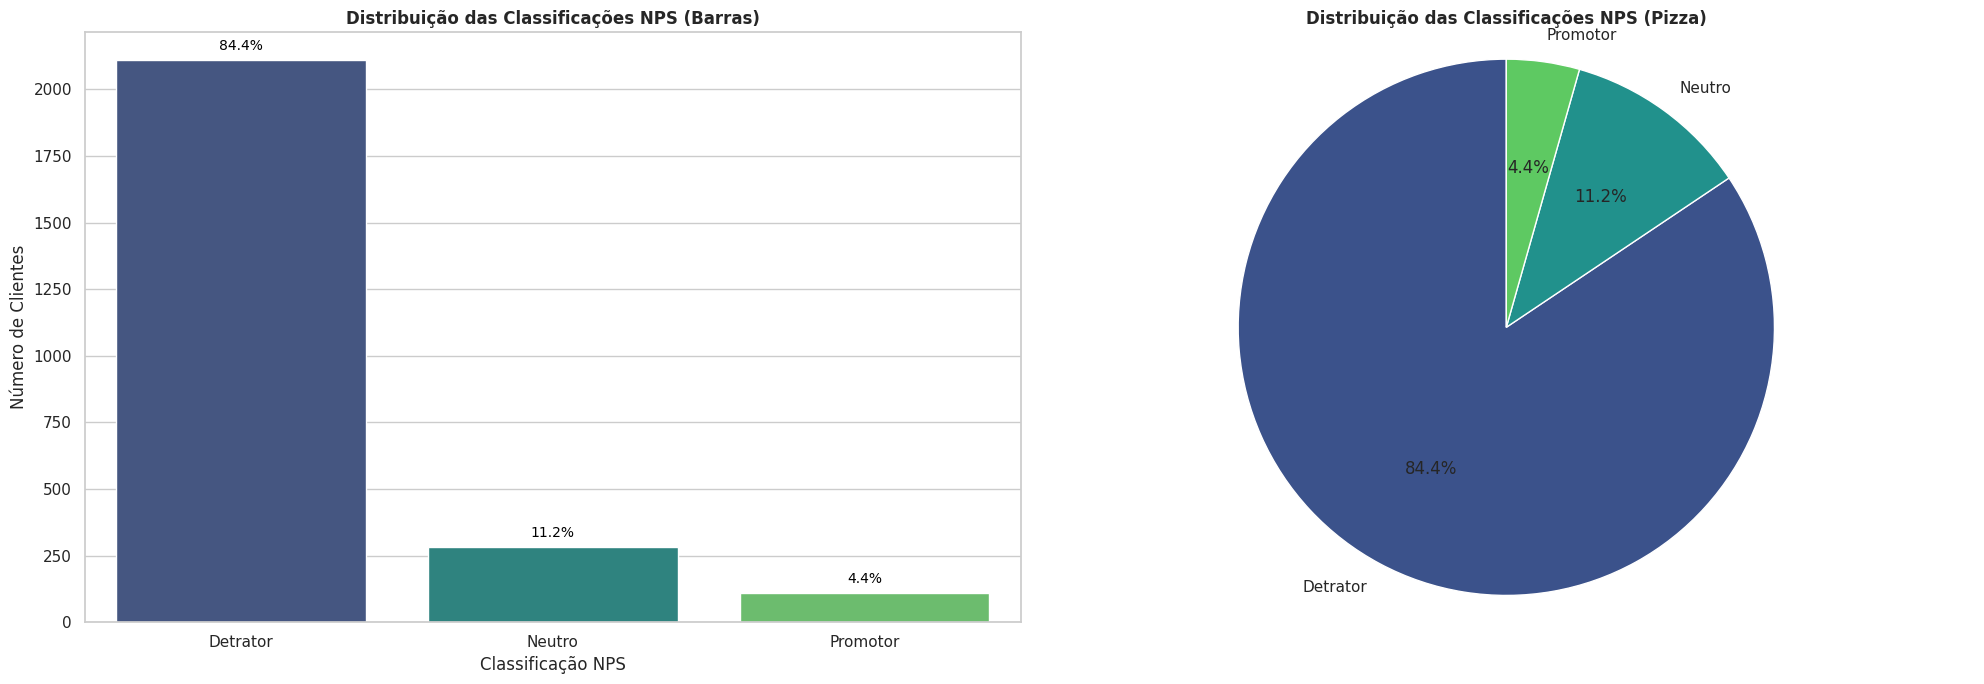

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # 1 linha, 2 colunas, tamanho maior

# Gráfico de Barras (countplot)
ax_count = sns.countplot(x='classificacao_nps', data=nps_df, palette='viridis', order=['Detrator', 'Neutro', 'Promotor'], ax=axes[0])
axes[0].set_title('Distribuição das Classificações NPS (Barras)', fontweight='bold')
axes[0].set_xlabel('Classificação NPS')
axes[0].set_ylabel('Número de Clientes')

# Adicionando Porcentagem ao gráfico de barras
total = len(nps_df['classificacao_nps'])
for p in ax_count.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax_count.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# Gráfico de Pizza (pie chart)
pie_values = [float(x.strip('%')) / 100 for x in percentual_nps.values]
axes[1].pie(pie_values, labels=percentual_nps.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(percentual_nps.index)))
axes[1].set_title('Distribuição das Classificações NPS (Pizza)', fontweight='bold')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

Podemos identificar que a maior parte dos clientes, é considerado um detrator. Com o nps_score geral, sendo extremamente negativo.



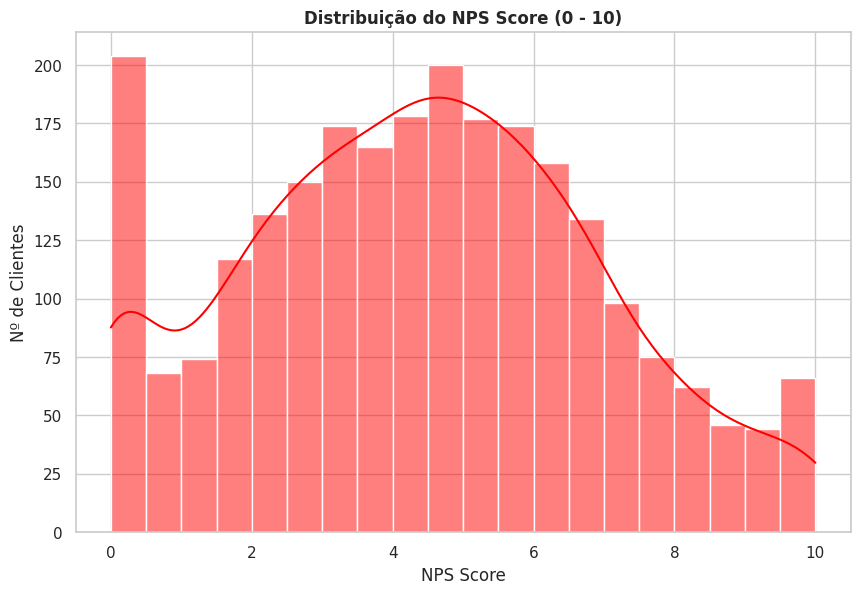

In [63]:
# distribuicao das notas de NPS

plt.figure(figsize=(10,6.5))
sns.histplot(nps_df.nps_score, bins=20, color='red', kde=True)
plt.ylabel('Nº de Clientes')
plt.xlabel('NPS Score')
plt.title('Distribuição do NPS Score (0 - 10)', fontweight='bold')
plt.show()

Com esse gráfico, podemos identificar que a maioria das notas, se acumulam entre os valores 2 e 7. Indicando que a experiência está sendo comprometida por algum fator que iremos investigar.

# 5. Estatística Descritiva

In [64]:
colunas_numericas = ['customer_age', 'customer_region',
       'customer_tenure_months',  'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score']

Utilizamos a estatística descritiva, para identificar padrões e ter uma visão geral de cada variável.

In [65]:
nps_df[colunas_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00
freight_value,2500.0,38.22,12.08,2.62,29.93,38.50,46.27,76.13
delivery_attempts,2500.0,2.01,0.82,1.00,1.00,2.00,3.00,3.00


# Utilizando correlação para identificar quais variáveis tem mais impacto direto na variável 'nps_score'.

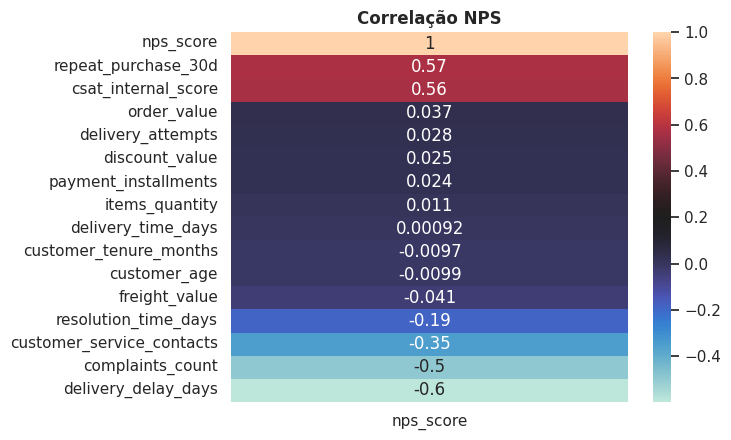

In [88]:
corre_colunas = [c for c in ['customer_age','customer_tenure_months',
      'order_value', 'items_quantity', 'discount_value', 'payment_installments',
      'delivery_time_days','delivery_delay_days', 'freight_value', 'delivery_attempts',
      'customer_service_contacts', 'resolution_time_days', 'nps_score',
      'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'] if c in nps_df.columns]

corr = nps_df[corre_colunas].corr(numeric_only=True)

corr_nps = corr[['nps_score']].sort_values(by='nps_score', ascending=False)

sns.heatmap(corr_nps, cmap='icefire', annot=True)
plt.title('Correlação NPS', fontweight='bold')
plt.tight_layout
plt.show()

Podemos identificar que as variáveis mais ligadas negativamente ao indíce de NPS, são as do pós vendas, com variáveis como (dias de atraso na entrega, número de reclamações, quantidade de contatos com o atendimento e o tempo de resolução em dias) estando diretamente relacionadas com as piores notas da variável 'nps_score'.

# 6. Análise Individual das Variáveis






###**Delivery Delay Days (Dias de Atraso na Entrega)**

In [67]:
delivery_delay = nps_df.groupby('delivery_delay_days').agg({'nps_score': ['mean', 'count']})
delivery_delay

nps_score      
                         mean count
delivery_delay_days                
0                    6.856679   277
1                    5.546179   615
2                    4.580186   646
3                    3.436762   525
4                    2.444444   270
5                    1.481034   116
6                    1.097059    34
7                    0.292857    14
8                    0.000000     3

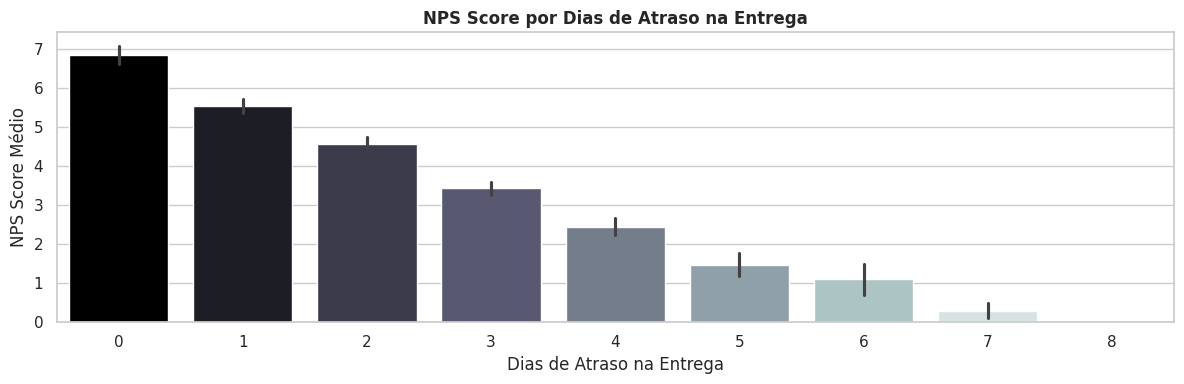

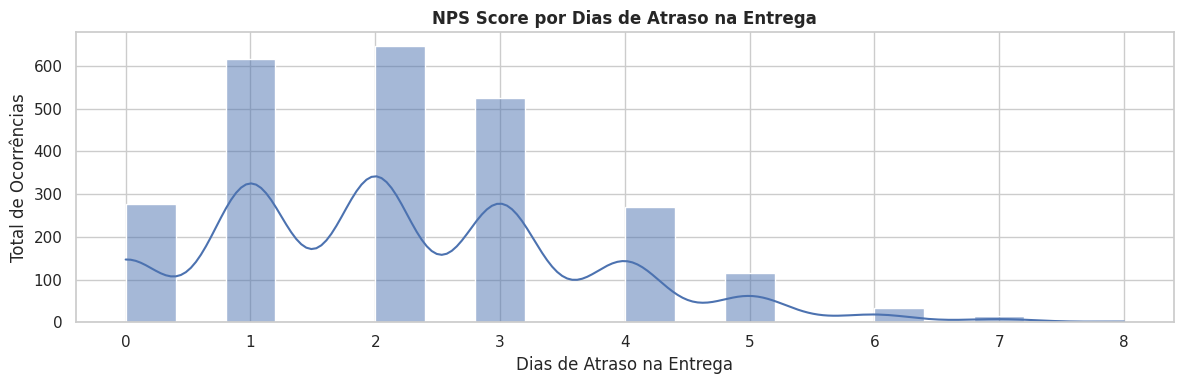

In [68]:

## Grafico de barras comparando nps_score com dias de atraso
plt.figure(figsize=(12, 4))
sns.barplot(x='delivery_delay_days', y='nps_score', palette='bone', data=nps_df, hue='delivery_delay_days', legend=False)
plt.title('NPS Score por Dias de Atraso na Entrega', fontweight='bold')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('NPS Score Médio')
plt.tight_layout()
## histograma comparando a quantidade de ocorrencias por dia de atraso

plt.figure(figsize=(12,4))
sns.histplot(nps_df.delivery_delay_days, bins=20, kde=True)

plt.title('NPS Score por Dias de Atraso na Entrega',  fontweight='bold')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('Total de Ocorrências')

plt.tight_layout()
plt.show()

Podemos identificar que para cada dia adicional de atraso temos uma redução na média do índice de nps.

Pedidos com 0 dias de atraso (no prazo), apresentam uma média de 6,8 que ficaria próximo aos clientes considerados neutros.

A incidência média de atrasos, gira em torno de 1 a 3 dias, com a máxima sendo 2 dias de atraso por pedido.

Acima de 1 dia de atraso, podemos considerar todos como detratores, com o índice se intensificando para cada dia adicional de atraso.




## **Complaints Counts (Número de Reclamações Registradas)**



In [69]:
reclamacoes = nps_df.groupby('complaints_count').agg({'nps_score': ['mean', 'count']})

display(reclamacoes)

nps_score      
                      mean count
complaints_count                
0                 8.517391    23
1                 7.770492   122
2                 6.052347   277
3                 4.910059   507
4                 4.219167   600
5                 3.645270   444
6                 3.062030   266
7                 2.813609   169
8                 2.065079    63
9                 2.487500    16
10                2.281818    11
11                0.850000     2

In [70]:
total_reclamacoes = nps_df['complaints_count'].value_counts()

display(total_reclamacoes)

,count
complaints_count,
4,600
3,507
5,444
2,277
6,266
7,169
1,122
8,63
0,23


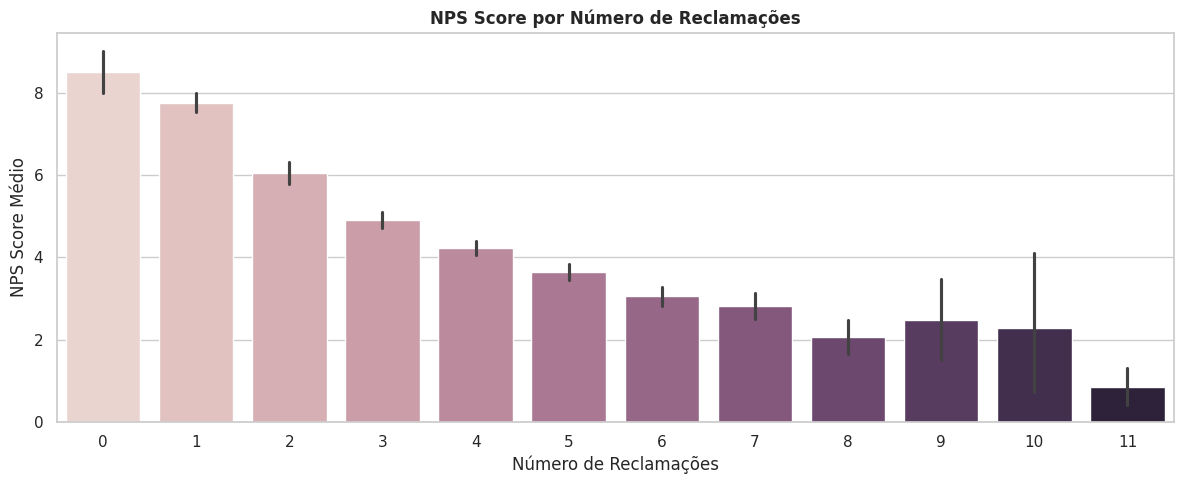

In [71]:
plt.figure(figsize=(12,5))
sns.barplot(x='complaints_count', y='nps_score', data=nps_df, hue='complaints_count', legend=False)
plt.title('NPS Score por Número de Reclamações', fontweight='bold')
plt.xlabel('Número de Reclamações')
plt.ylabel('NPS Score Médio')
plt.tight_layout()
plt.show()

 Como já haviamos identificado ao analisar o nps por dias de atraso, podemos identificar o mesmo padrão quando analisamos a variável 'número de reclamações'.

Para casos onde não há reclamações, o nps médio tende a se manter alto. Quanto maior o índice de reclamações, a tendência de diminuição do nps_score aumenta e consequentemente o índice de detratores também.

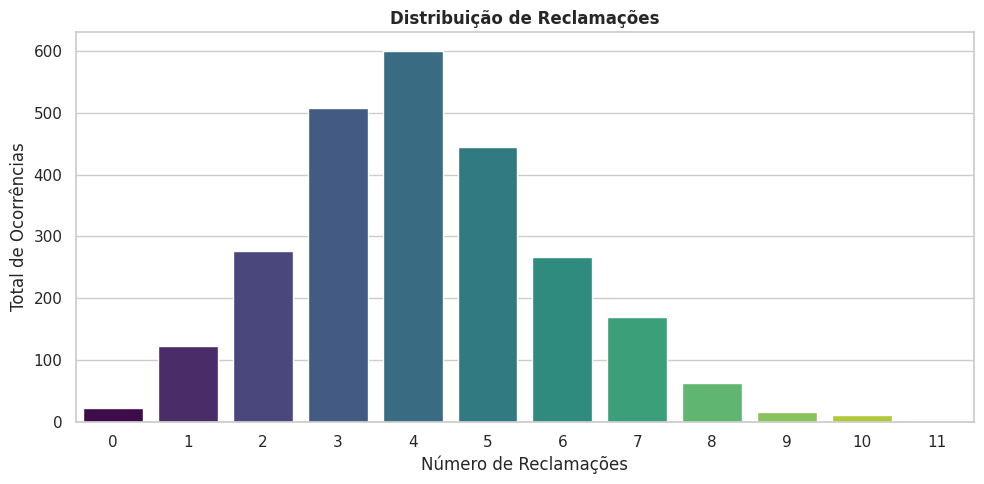

In [ ]:
plt.figure(figsize=(12, 5))
# Convertendo a Series total_reclamacoes em um DataFrame para plotar com Seaborn
total_reclamacoes_df = total_reclamacoes.reset_index()
total_reclamacoes_df.columns = ['complaints_count', 'count']

sns.barplot(x='complaints_count', y='count', data=total_reclamacoes_df, palette='viridis', hue='complaints_count', legend=False)
plt.title('Distribuição de Reclamações', fontweight='bold')
plt.xlabel('Número de Reclamações')
plt.ylabel('Total de Ocorrências')
plt.tight_layout()
plt.show()

## **Customer Service Contacts (Contatos com o Atendimento)**

In [73]:
contatos_atendimento = nps_df.groupby('customer_service_contacts').agg({'nps_score': ['mean', 'count']})

display(contatos_atendimento)

nps_score      
                               mean count
customer_service_contacts                
0                          5.543502   554
1                          4.657108   816
2                          4.116406   640
3                          3.201911   314
4                          2.654545   132
5                          2.238235    34
6                          0.742857     7
7                          1.200000     3

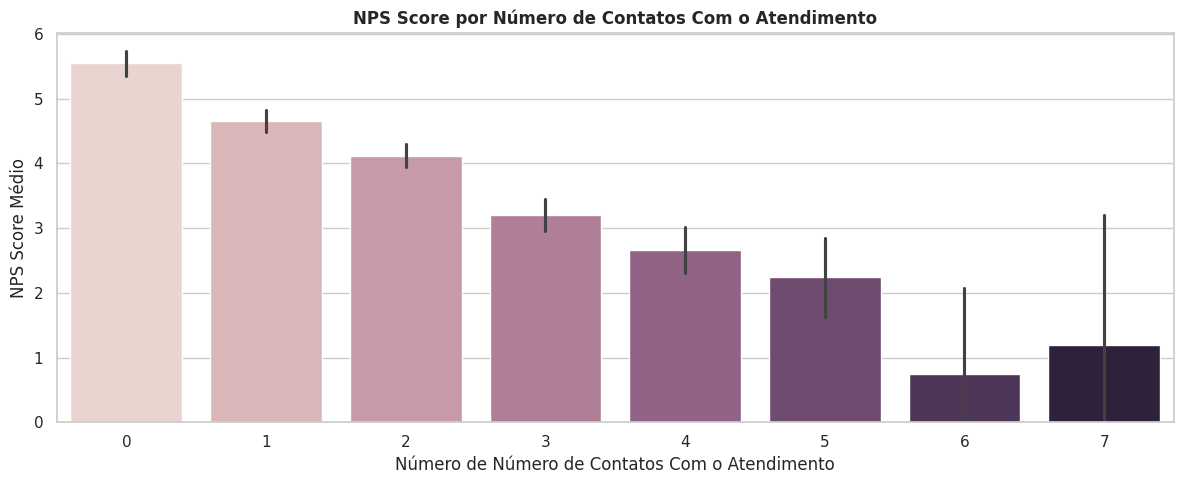

In [74]:
plt.figure(figsize=(12,5))
sns.barplot(x='customer_service_contacts', y='nps_score', data=nps_df, hue='customer_service_contacts', legend=False)
plt.title('NPS Score por Número de Contatos Com o Atendimento', fontweight='bold')
plt.xlabel('Número de Número de Contatos Com o Atendimento')
plt.ylabel('NPS Score Médio')
plt.tight_layout()
plt.show()

 contatos repetidos com o atendimento também derrubam o NPS de forma consistente. Isso sugere que precisar contatar o atendimento mais de uma vez já é, por si só, um sinal de experiência ruim.

# 7. Analisando os Perfis dos Clientes

In [75]:
nps_df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,classificacao_nps
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Detrator
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Detrator


## Verificando a média do nps de acordo com a faixa etária dos clientes.

In [76]:
nps_df['faixa_etaria'] = pd.cut(nps_df['customer_age'], bins=[0, 18, 30, 45, 60, 75])
nps_df.groupby('faixa_etaria').agg({'nps_score': ['mean', 'count', 'median']}).round(2)

/tmp/ipykernel_2473/1523978314.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nps_df.groupby('faixa_etaria').agg({'nps_score': ['mean', 'count', 'median']}).round(2)


nps_score             
                  mean count median
faixa_etaria                       
(0, 18]           4.36    42    4.4
(18, 30]          4.55   560    4.5
(30, 45]          4.24   769    4.3
(45, 60]          4.29   714    4.4
(60, 75]          4.56   415    4.5

## Verificando a média do nps de acordo com o período em meses como cliente do negócio.




In [77]:
nps_df['meses_como_cliente'] = pd.cut(nps_df['customer_tenure_months'], bins=[0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120])
nps_df.groupby('meses_como_cliente').agg({'nps_score': ['mean', 'count', 'median']}).round(2)

/tmp/ipykernel_2473/1071959803.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nps_df.groupby('meses_como_cliente').agg({'nps_score': ['mean', 'count', 'median']}).round(2)


nps_score             
                        mean count median
meses_como_cliente                       
(0, 12]                 4.15   242   4.10
(12, 24]                4.65   247   4.70
(24, 36]                4.45   243   4.70
(36, 48]                4.25   230   4.30
(48, 60]                4.34   248   4.35
(60, 72]                4.73   249   4.70
(72, 84]                4.35   293   4.30
(84, 96]                4.34   250   4.35
(96, 108]               4.16   240   4.10
(108, 120]              4.35   258   4.50

## Verificando a média do nps de acordo com a região dos clientes.

In [78]:
nps_df.groupby('customer_region').agg({'nps_score': ['mean', 'count', 'median']}).round(2)

nps_score             
                     mean count median
customer_region                       
Centro-Oeste         4.21   468    4.2
Nordeste             4.42   485    4.5
Norte                4.38   506    4.5
Sudeste              4.37   520    4.3
Sul                  4.49   521    4.5

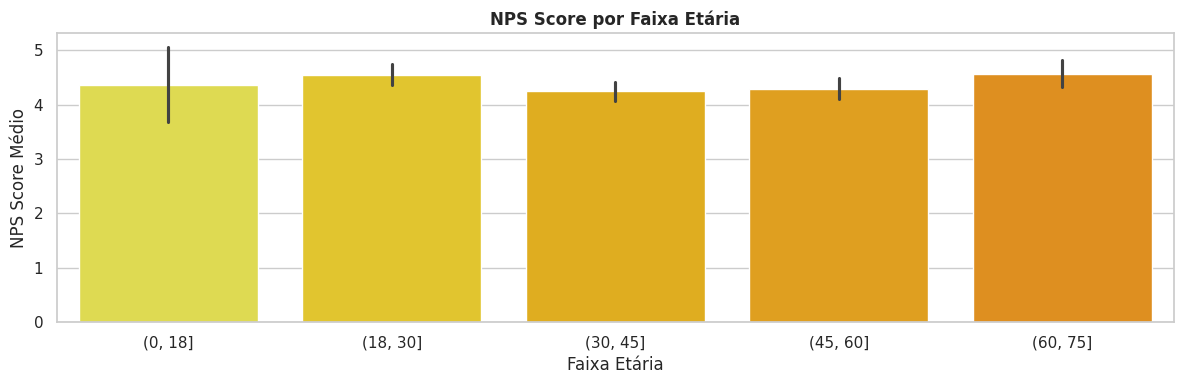

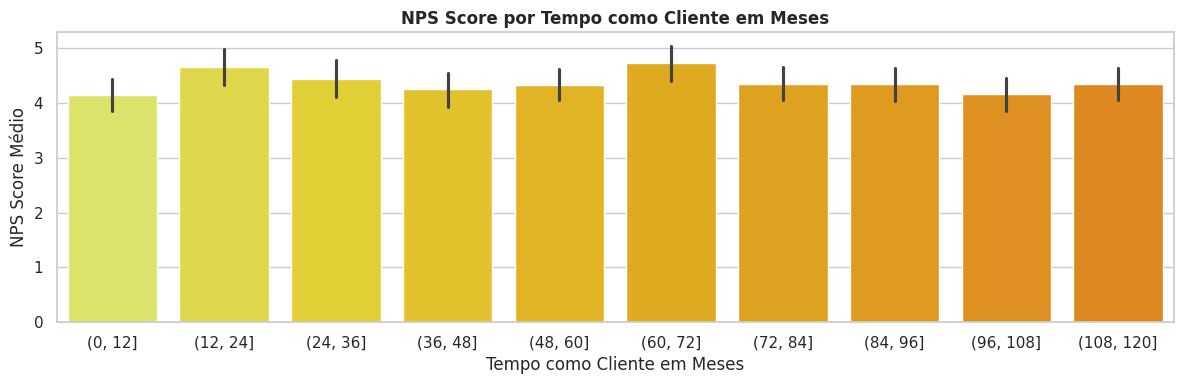

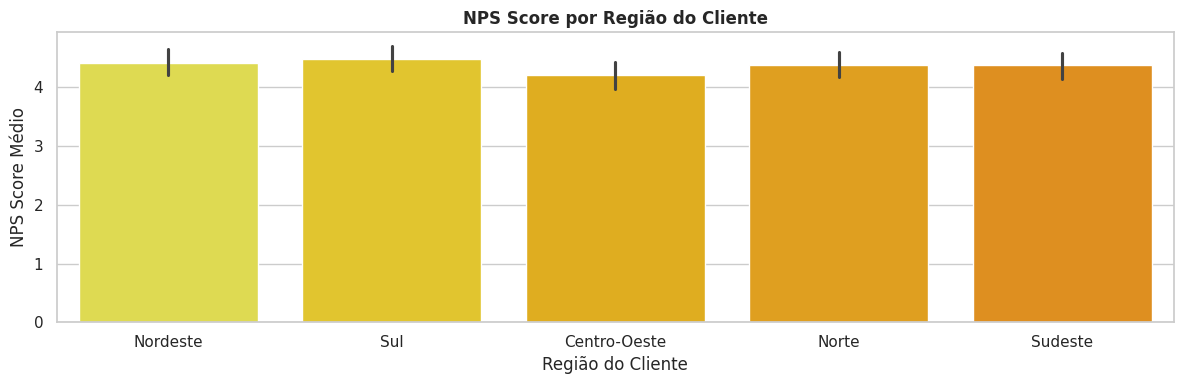

In [79]:
plt.figure(figsize=(12, 4))
sns.barplot(x='faixa_etaria', y='nps_score', palette='Wistia', data=nps_df, hue='faixa_etaria', legend=False)
plt.title('NPS Score por Faixa Etária', fontweight='bold')
plt.xlabel('Faixa Etária')
plt.ylabel('NPS Score Médio')
plt.tight_layout()

plt.figure(figsize=(12, 4))
sns.barplot(x='meses_como_cliente', y='nps_score', palette='Wistia', data=nps_df, hue='meses_como_cliente', legend=False)
plt.title('NPS Score por Tempo como Cliente em Meses', fontweight='bold')
plt.xlabel('Tempo como Cliente em Meses')
plt.ylabel('NPS Score Médio')
plt.tight_layout()

plt.figure(figsize=(12, 4))
sns.barplot(x='customer_region', y='nps_score', palette='Wistia', data=nps_df, hue='customer_region', legend=False)
plt.title('NPS Score por Região do Cliente', fontweight='bold')
plt.xlabel('Região do Cliente')
plt.ylabel('NPS Score Médio')
plt.tight_layout()

plt.show()

Podemos notar, que por mais que existam diferentes perfis de clientes, temos um padrão que tende a não mudar.

Analisamos faixa etária, tempo como cliente e região. Identificamos que não existe um padrão de cliente que se destaque, tanto para promotor, quanto para detrator da marca.

Com isso, podemos identificar que o maior gargalo em relação ao índice de NPS, não está nos diferentes tipos de clientes, mas sim, no processo operacional da empresa.

# 8. Recompra, a varíavel com melhor correlação com o NPS.

In [90]:
recompra_por_categoria = nps_df.groupby("classificacao_nps")["repeat_purchase_30d"].mean().reindex(
    ["Detrator", "Neutro", "Promotor"]
) *100
print("Taxa de recompra em 30 dias, por categoria de NPS:")
print(recompra_por_categoria.round(1))

Taxa de recompra em 30 dias, por categoria de NPS:
classificacao_nps
Detrator      0.0
Neutro       38.4
Promotor    100.0
Name: repeat_purchase_30d, dtype: float64


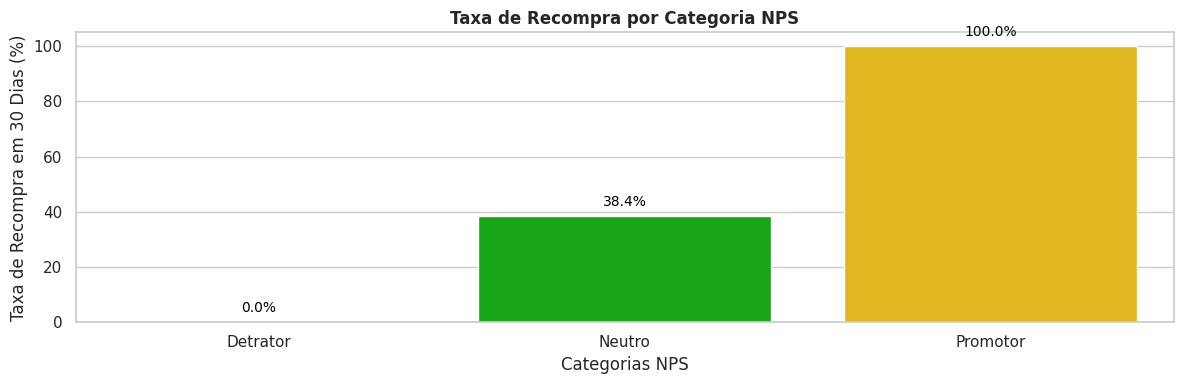

In [86]:
plt.figure(figsize=(12, 4))

# Converte a series em um Dataframe
recompra_df = recompra_por_categoria.reset_index()
recompra_df.columns = ['classificacao_nps', 'taxa_recompra']

ax = sns.barplot(x='classificacao_nps', y='taxa_recompra', palette='nipy_spectral', data=recompra_df, hue='classificacao_nps', legend=False, order=["Detrator", "Neutro", "Promotor"])
plt.title('Taxa de Recompra por Categoria NPS', fontweight='bold')
plt.xlabel('Categorias NPS')
plt.ylabel('Taxa de Recompra em 30 Dias (%)')

# Adicionando Porcentagem acima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=10, color='black')

plt.tight_layout()
plt.show()

Clientes promotores (NPS_score entre 9 e 10) recompram os produtos com muito mais frequência no curto prazo (até 30 dias), enquanto clientes detratores tendem a não seguir comprando novamente.

# 9. Conclusão



1.   **Satisfação Geral** - O índice de NPS está apresentando resultados críticos, com mais de 80% dos clientes sendo considerados detratores.

2.   **Principais Fatores de Insatisfação** - O principal fator que está associado a insatisfação, é 'Dias de Atraso na Entrega' com correlação de -0,6 com o NPS Score, seguido por 'Número de Reclamações' e 'Contatos com o Atendimento', com correlações de -0,5 e -0,35 respectivamente. O gargalo no processo operacional, tem sido em maior parte no pós-vendas.

3.   **O Impacto Não Está Relacionado com Perfis de Clientes** - Quando analisamos os clientes por diferentes perfis, como 'Faixa Etária', 'Região' e 'Tempo como Cliente', não identificamos nenhum perfil padrão que possa ser considerado um detrator. Com isso, podemos perceber que o maior problema não está no cliente em si, mas no processo operacional.


